# El aire del sur de Europa carga más del triple de polvo del desierto que el del norte

Y hay un hilo de hielo en los Alpes que muestra que esa carga **se duplicó en poco más de un siglo**.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Rising dust pollution across Europe in a changing climate* — Vasilakos et al., **Nature** (2026)
**DOI:** [10.1038/s41586-026-10743-w](https://doi.org/10.1038/s41586-026-10743-w)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-15-dust-pollution-europa/notebook.ipynb)

> Notebook reproducible de **Ciencia a Mordiscos** · [cienciaamordiscos.com](https://cienciaamordiscos.com)

## De dónde viene el polvo que respiras

El polvo mineral del desierto no se queda en el desierto. El viento levanta partículas del Sáhara y el Sahel y las empuja miles de kilómetros hacia el norte, hasta que caen sobre los pulmones, los tejados y los glaciares de Europa. Ese polvo es una parte enorme del material particulado que flota en el aire — el mismo que en los episodios fuertes irrita el asma y ensucia el cielo.

El equipo hizo dos cosas: **juntó** mediciones de polvo de 106 estaciones repartidas por toda Europa, y **leyó** un núcleo de hielo alpino que guarda, año a año, cuánto polvo llegó desde 1750. Con eso responde una pregunta que llevaba tiempo sin cerrarse: ¿está subiendo el polvo que respira Europa, y por qué?

Nosotros abrimos esos mismos datos y los miramos de cerca.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
LAT_CORTE      = 45          # frontera norte/sur en grados N (mueve esta línea)
COLOR_SUR      = '#DC2626'   # sur = más polvo (rojo/alerta)
COLOR_NORTE    = '#2563EB'   # norte = menos polvo (azul CaM)
COLOR_REF      = '#D97706'   # referencia / umbrales (ámbar)
FUENTE = 'Fuente: Vasilakos et al. (2026), Nature | Datos: Zenodo 10.5281/zenodo.19236528'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos (local datos/ → fallback GitHub raw del repo)
def cargar(nombre):
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        ruta = f'{BASE}/papers/%s/datos/{nombre}' % '2026-07-15-dust-pollution-europa'
    return pd.read_csv(ruta)

grad   = cargar('gradiente_sitios.csv')     # 106 estaciones: lat, lon, Al trazador
hielo  = cargar('icecore_ca.csv')           # núcleo de hielo: año, Ca raw, Ca suavizado
sequia = cargar('sequia_polvo.csv')         # Ca suavizado vs índice de sequía
ciclo  = cargar('ciclo_estacional.csv')     # ciclo mensual normalizado

print(f'Estaciones europeas: {len(grad)}')
print(f'Núcleo de hielo: {len(hielo)} años ({int(hielo.anio.min())}–{int(hielo.anio.max())})')
print(f'Frontera norte/sur en {LAT_CORTE}°N')

Estaciones europeas: 106
Núcleo de hielo: 271 años (1750–2020)
Frontera norte/sur en 45°N


## Aquí está el gradiente.

Cada punto es una estación. El eje horizontal es la latitud: a la izquierda, el sur cálido; a la derecha, el norte.

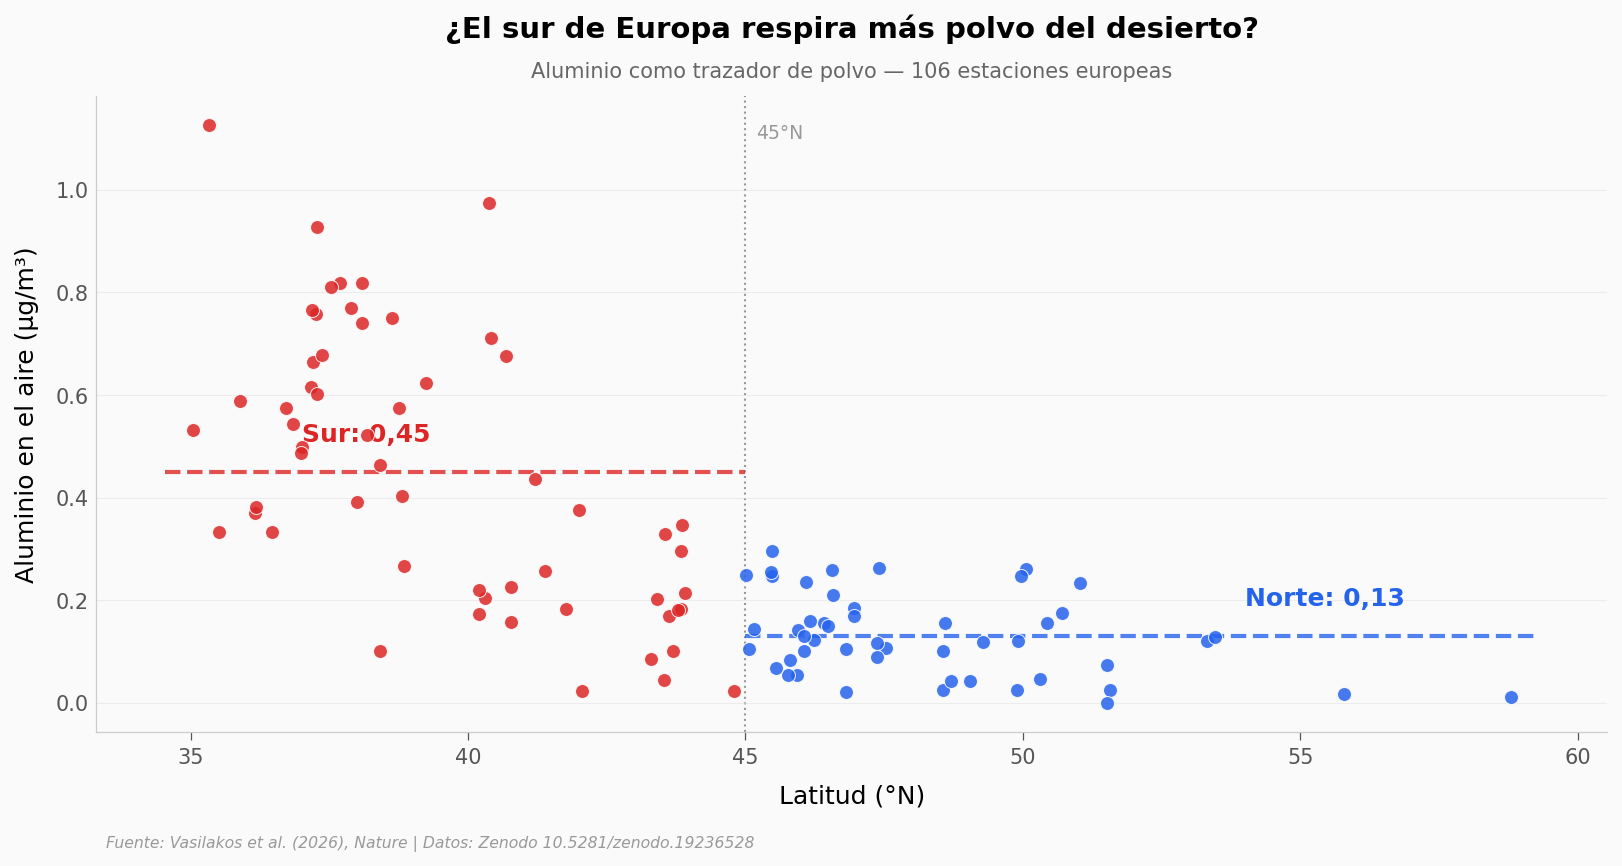

Sur (n=57): 0.449 µg/m³   Norte (n=49): 0.130 µg/m³
El sur carga 3.45× más polvo (trazador Al)
Latitud vs polvo — Spearman ρ = -0.747, p = 3.8e-20


In [2]:
# Trazamos el aluminio (Al) como huella del polvo mineral: cuanto más Al en el aire,
# más polvo del desierto. NO es lo mismo que el PM10 modelado del paper — es el
# elemento medido directamente, un trazador limpio del polvo.
sur   = grad[grad.latitud <  LAT_CORTE]
norte = grad[grad.latitud >= LAT_CORTE]
al_sur, al_norte = sur.al_mean_ugm3.mean(), norte.al_mean_ugm3.mean()
ratio = al_sur / al_norte

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.scatter(norte.latitud, norte.al_mean_ugm3, color=COLOR_NORTE, s=45, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)
ax.scatter(sur.latitud, sur.al_mean_ugm3, color=COLOR_SUR, s=45, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)

# medias por grupo como líneas horizontales
ax.hlines(al_sur, grad.latitud.min()-0.5, LAT_CORTE, color=COLOR_SUR,
          linewidth=2, linestyle='--', alpha=0.8, zorder=4)
ax.hlines(al_norte, LAT_CORTE, grad.latitud.max()+0.5, color=COLOR_NORTE,
          linewidth=2, linestyle='--', alpha=0.8, zorder=4)
ax.axvline(LAT_CORTE, color='#999999', linewidth=1, linestyle=':', zorder=1)

# etiquetas inline (sin caja de leyenda)
ax.text(37, al_sur+0.06, f'Sur: {al_sur:.2f}'.replace('.', ','), color=COLOR_SUR,
        fontsize=12, fontweight='bold')
ax.text(54, al_norte+0.06, f'Norte: {al_norte:.2f}'.replace('.', ','), color=COLOR_NORTE,
        fontsize=12, fontweight='bold')
ax.text(LAT_CORTE+0.2, ax.get_ylim()[1]*0.93, f'{LAT_CORTE}°N',
        color='#999999', fontsize=9)

ax.set_title('¿El sur de Europa respira más polvo del desierto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Aluminio como trazador de polvo — 106 estaciones europeas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Latitud (°N)')
ax.set_ylabel('Aluminio en el aire (µg/m³)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/gradiente_hero.png', dpi=200, bbox_inches='tight')
plt.show()

rho, p = stats.spearmanr(grad.latitud, grad.al_mean_ugm3)
print(f'Sur (n={len(sur)}): {al_sur:.3f} µg/m³   Norte (n={len(norte)}): {al_norte:.3f} µg/m³')
print(f'El sur carga {ratio:.2f}× más polvo (trazador Al)')
print(f'Latitud vs polvo — Spearman ρ = {rho:.3f}, p = {p:.1e}')

La caída es limpia y ordenada: subir en latitud es bajar en polvo. La correlación de rangos es fuerte (ρ = −0,75, con una probabilidad de azar minúscula), y la brecha entre las medias es grande — el sur carga unas **3,4 veces** más trazador de polvo que el norte.

Un detalle honesto: este número (3,4×) es del **aluminio**, el elemento que se mide directo en el aire. El paper también estima el **PM10 de polvo** con un modelo, y ahí el sur sale unas 2,5 veces por encima del norte. Son dos formas de medir lo mismo — el trazador crudo y el modelo — y las dos apuntan al mismo lado: el sur respira bastante más polvo del desierto. Las magnitudes no son idénticas porque no son la misma variable.

## Ahora, el tiempo.

El gradiente nos dice *dónde* hay más polvo. La siguiente pregunta es *cuándo*: ¿esto siempre fue así, o el polvo está subiendo? Para eso hay un archivo poco común — un núcleo de hielo de los Alpes que atrapó, capa sobre capa, el calcio que viaja pegado al polvo del desierto desde 1750.

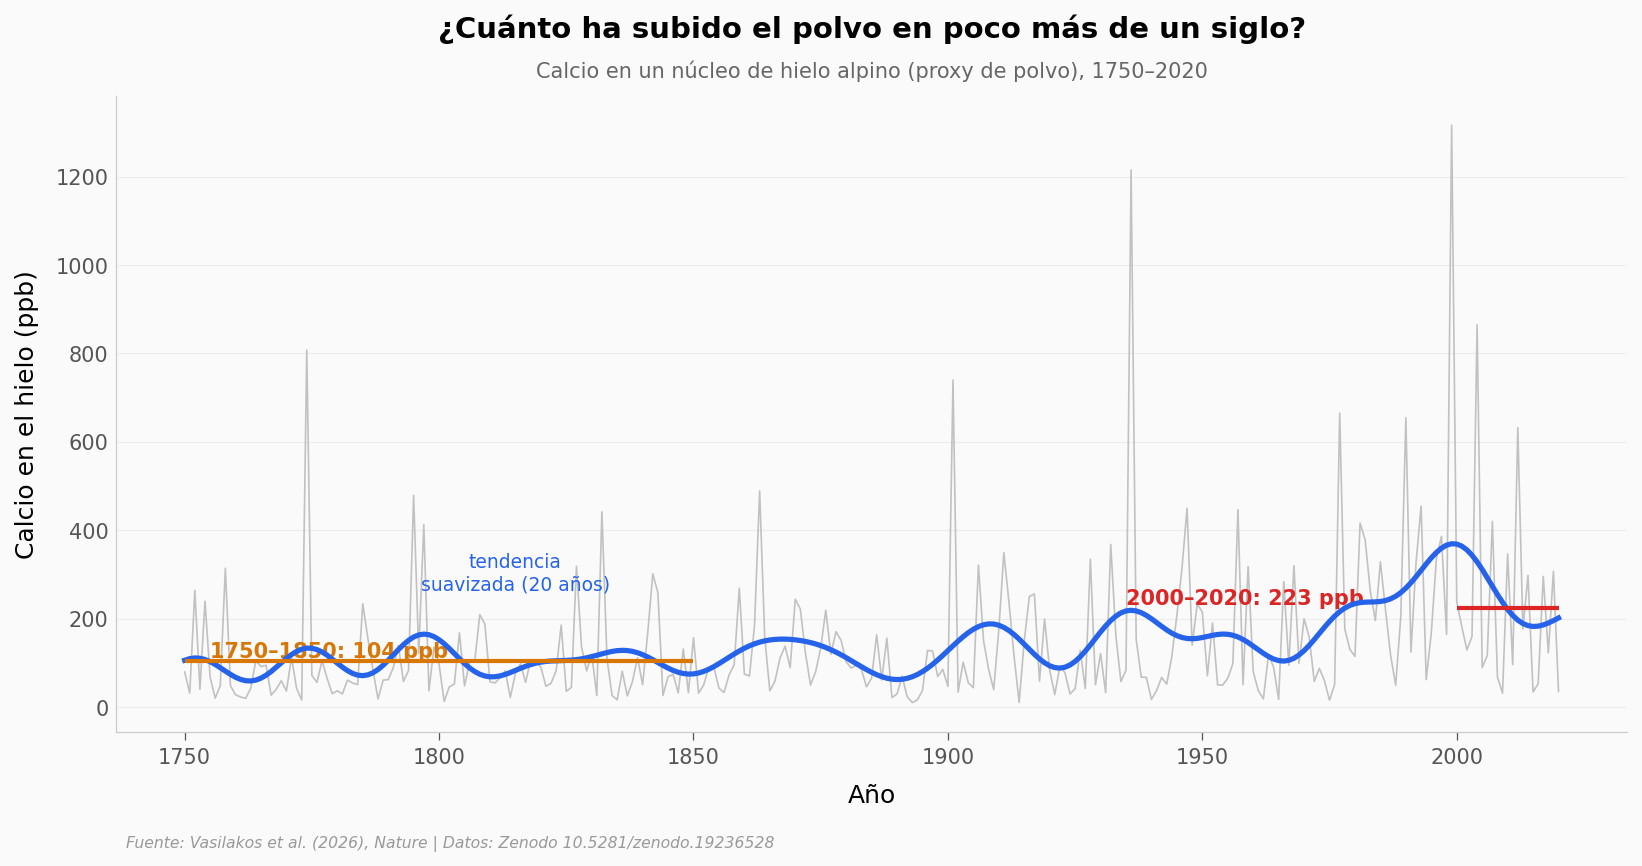

Media preindustrial (1750–1850): 104.5 ppb
Media reciente (2000–2020): 223.5 ppb
Aumento: +114%  (el paper reporta +110%)


In [3]:
# El calcio (Ca) del hielo es un proxy del polvo: más polvo del desierto → más calcio atrapado.
# La señal año a año es ruidosa (tormentas puntuales), así que el paper también trae
# una versión suavizada a 20 años (LPF) para ver la tendencia de fondo.
preind = hielo[(hielo.anio >= 1750) & (hielo.anio <= 1850)].ca_ppb_raw.mean()
recie  = hielo[(hielo.anio >= 2000) & (hielo.anio <= 2020)].ca_ppb_raw.mean()
subida = (recie / preind - 1) * 100

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(hielo.anio, hielo.ca_ppb_raw, color='#BBBBBB', linewidth=0.8, alpha=0.9, zorder=2)
ax.plot(hielo.anio, hielo.ca_ppb_lpf20yr, color=COLOR_NORTE, linewidth=2.5, zorder=4)

# bandas de referencia: media preindustrial vs reciente
ax.hlines(preind, 1750, 1850, color=COLOR_REF, linewidth=2, zorder=5)
ax.hlines(recie, 2000, 2020, color=COLOR_SUR, linewidth=2, zorder=5)
ax.text(1755, preind+8, f'1750–1850: {preind:.0f} ppb'.replace('.', ','),
        color=COLOR_REF, fontsize=10, fontweight='bold')
ax.text(1935, recie+8, f'2000–2020: {recie:.0f} ppb'.replace('.', ','),
        color=COLOR_SUR, fontsize=10, fontweight='bold')
ax.text(1815, hielo.ca_ppb_lpf20yr.max()*0.72, 'tendencia\nsuavizada (20 años)',
        color=COLOR_NORTE, fontsize=9, ha='center')

ax.set_title('¿Cuánto ha subido el polvo en poco más de un siglo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Calcio en un núcleo de hielo alpino (proxy de polvo), 1750–2020',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año')
ax.set_ylabel('Calcio en el hielo (ppb)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hielo_temporal.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Media preindustrial (1750–1850): {preind:.1f} ppb')
print(f'Media reciente (2000–2020): {recie:.1f} ppb')
print(f'Aumento: +{subida:.0f}%  (el paper reporta +110%)')

## ¿Y por qué sube?

El hielo dice *cuánto* subió, pero no *por qué*. La pista está al otro lado del Mediterráneo. Cuando el norte de África se seca, el suelo desnudo suelta más polvo al viento — y ese polvo termina en el hielo alpino. Podemos ponerlo a prueba cruzando el calcio del hielo con un índice de sequía de Marruecos (el PDSI: valores negativos = más seco).

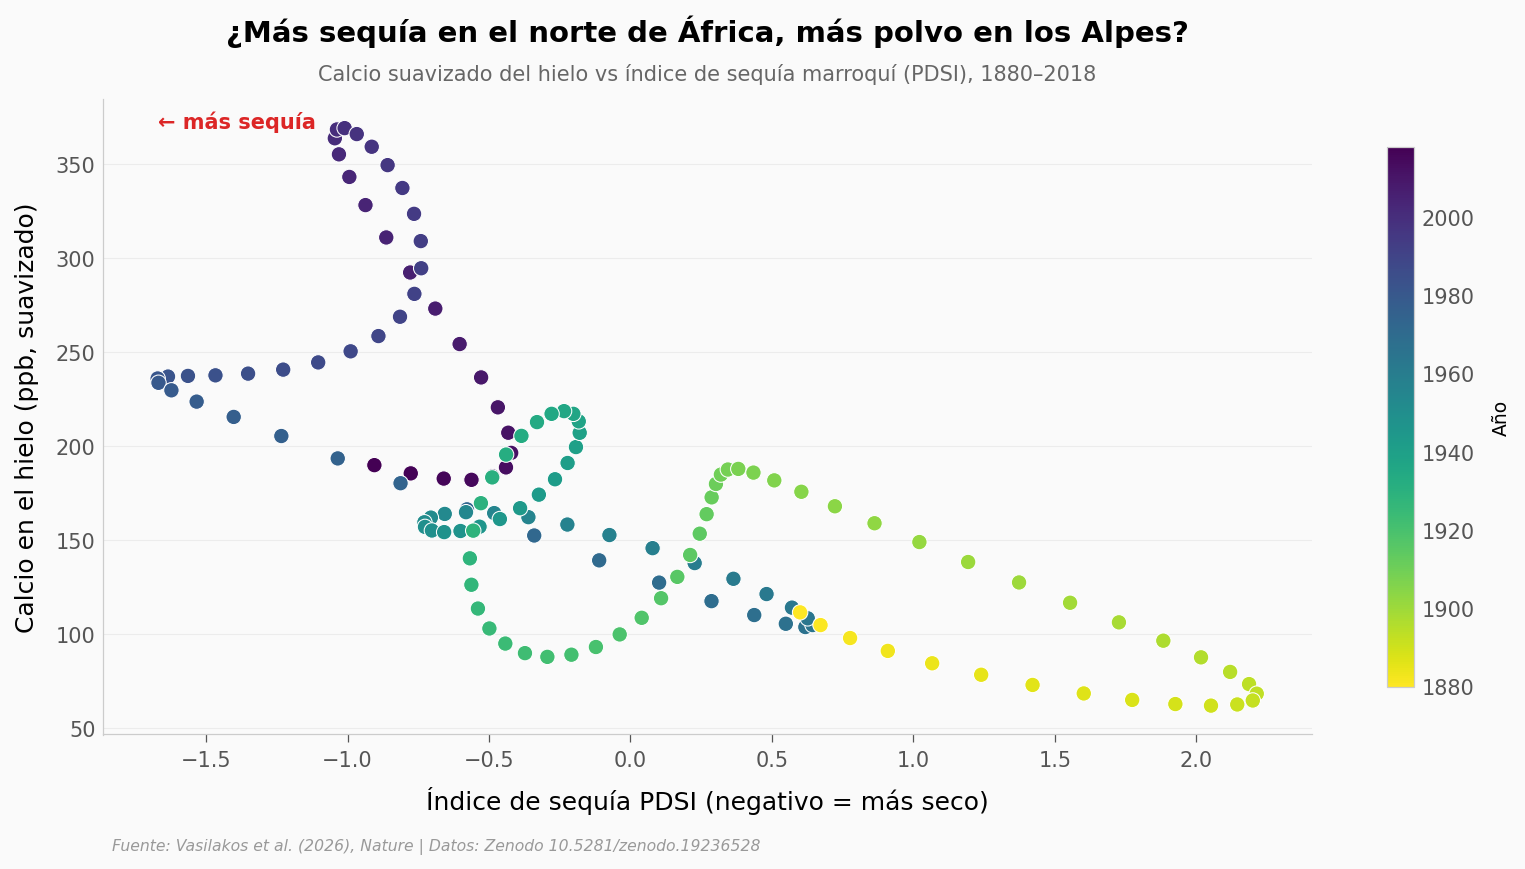

Calcio vs sequía — Spearman ρ = -0.778, p = 2.2e-29  (n = 139 años)


In [4]:
# PDSI negativo = más sequía. Si la sequía africana empuja el polvo,
# esperaríamos: más sequía (PDSI bajo) → más calcio (más polvo).
m = sequia.dropna(subset=['ca_ppb_lpf20yr', 'pdsi_marruecos'])
rho_s, p_s = stats.spearmanr(m.ca_ppb_lpf20yr, m.pdsi_marruecos)

fig, ax = plt.subplots(figsize=(13, 5.5))
sc = ax.scatter(m.pdsi_marruecos, m.ca_ppb_lpf20yr, c=m.anio, cmap='viridis_r',
                s=55, edgecolors='white', linewidths=0.5, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('Año', fontsize=9)

ax.annotate('← más sequía', xy=(m.pdsi_marruecos.min(), m.ca_ppb_lpf20yr.max()),
            fontsize=10, color=COLOR_SUR, fontweight='bold')

ax.set_title('¿Más sequía en el norte de África, más polvo en los Alpes?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Calcio suavizado del hielo vs índice de sequía marroquí (PDSI), 1880–2018',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Índice de sequía PDSI (negativo = más seco)')
ax.set_ylabel('Calcio en el hielo (ppb, suavizado)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sequia_polvo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Calcio vs sequía — Spearman ρ = {rho_s:.3f}, p = {p_s:.1e}  (n = {len(m)} años)')

La nube de puntos baja hacia la derecha: los años más secos (PDSI bajo) son también los de más polvo. La correlación es fuerte (ρ = −0,78), y el color muestra que los años recientes se agolpan arriba a la izquierda — más secos y más polvorientos a la vez. Todo apunta a que la sequía norteafricana está detrás de la subida.

Cuidado con la palabra fácil: esto es una **asociación** medida sobre lo que ya pasó, no un experimento. Nadie secó África para ver qué pasaba. Que dos cosas se muevan juntas tan de cerca es una pista muy fuerte, pero el mecanismo exacto sigue siendo terreno de modelos.

## Una última pregunta: ¿qué tan lejos del pasado estamos?

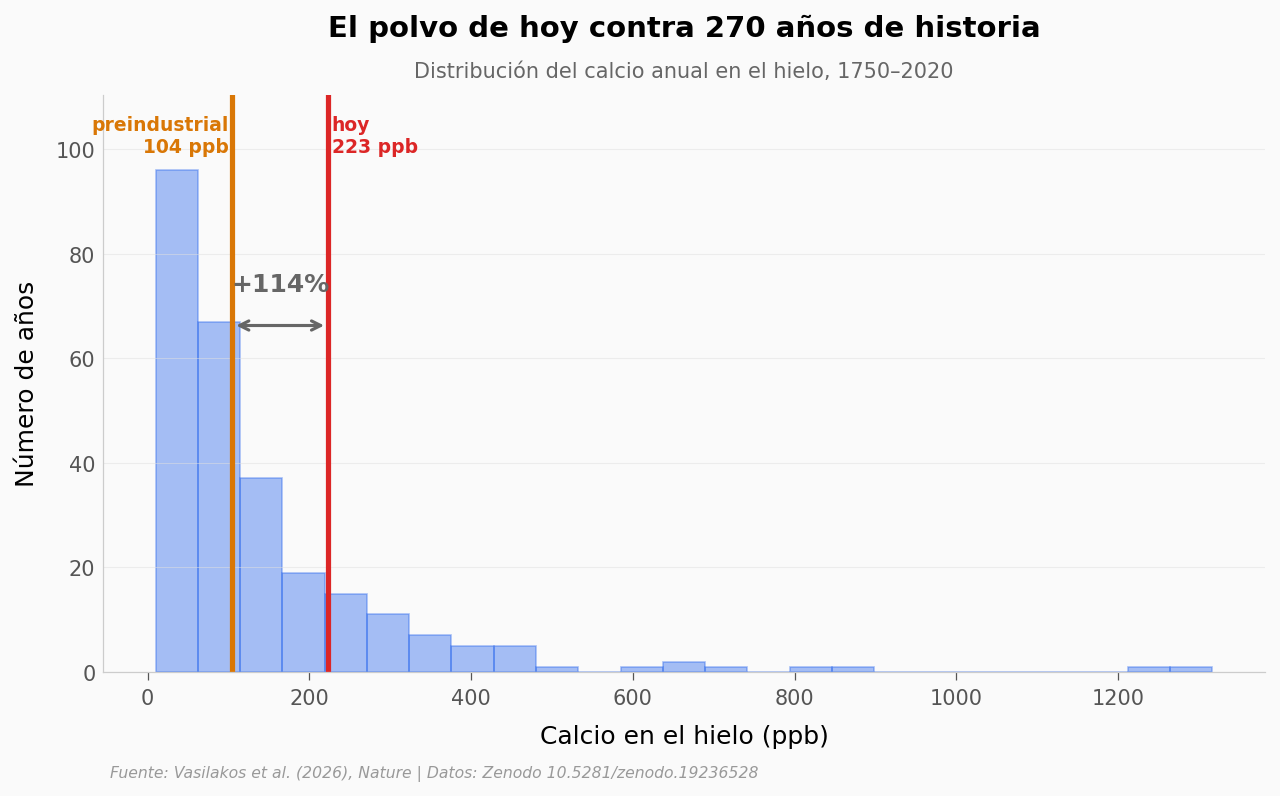

La media reciente (223 ppb) está muy por encima de la preindustrial (104 ppb).


In [5]:
# ¿El nivel actual es raro comparado con dos siglos y medio de historia?
fig, ax = plt.subplots(figsize=(10, 5))
datos = hielo.ca_ppb_raw.dropna()
n, bins, patches = ax.hist(datos, bins=25, color=COLOR_NORTE, alpha=0.4,
                           edgecolor=COLOR_NORTE, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(preind, color=COLOR_REF, linewidth=2.5)
ax.axvline(recie, color=COLOR_SUR, linewidth=2.5)
ax.annotate('', xy=(recie, y_max*0.6), xytext=(preind, y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((preind+recie)/2, y_max*0.66, f'+{subida:.0f}%', ha='center',
        fontsize=12, fontweight='bold', color='#666666')
ax.text(preind-4, y_max*0.9, f'preindustrial\n{preind:.0f} ppb'.replace('.', ','),
        color=COLOR_REF, fontsize=9, ha='right', fontweight='bold')
ax.text(recie+4, y_max*0.9, f'hoy\n{recie:.0f} ppb'.replace('.', ','),
        color=COLOR_SUR, fontsize=9, ha='left', fontweight='bold')

ax.set_title('El polvo de hoy contra 270 años de historia',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del calcio anual en el hielo, 1750–2020',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Calcio en el hielo (ppb)')
ax.set_ylabel('Número de años')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_hist.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'La media reciente ({recie:.0f} ppb) está muy por encima de la preindustrial ({preind:.0f} ppb).')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El sur de Europa carga más polvo que el norte | ✅ | Trazador Al: sur 0,45 vs norte 0,13 µg/m³ (**3,4×**). Latitud vs Al: Spearman ρ = −0,75, p ≈ 4·10⁻²⁰, n = 106 estaciones |
| El polvo subió fuerte desde la era preindustrial | ✅ | Calcio del hielo: 104 ppb (1750–1850) → 223 ppb (2000–2020) = **+114 %** (raw). El paper reporta **+110 %** — consistente |
| La subida va asociada a la sequía norteafricana | ⚠️ | Calcio vs sequía marroquí: Spearman ρ = −0,78, p ≈ 2·10⁻²⁹, n = 139 años. **Asociación fuerte, no causa probada** (diseño observacional) |
| Hay un ciclo estacional claro del polvo | ✅ | Máximo en **junio–agosto**, mínimo en **diciembre–enero** (celda de abajo) |

> **Limitaciones:** (1) El aluminio (trazador) y el PM10 de polvo (modelo) son variables distintas — coinciden en el gradiente sur>norte, pero sus magnitudes (3,4× vs 2,5×) no son intercambiables. (2) El núcleo de hielo es un solo punto en los Alpes; captura la señal regional del polvo, no el promedio de toda Europa. (3) Las correlaciones con la sequía son sobre datos suavizados a 20 años, lo que sube la correlación pero también reduce los grados de libertad reales. (4) El vínculo polvo–salud que menciona el paper es una asociación reportada por los investigadores, no algo que reproduzcamos aquí.

## Ahora tú

1. **¿Dónde pones la frontera?** En la celda de configuración, cambia `LAT_CORTE` de `45` a `50`. ¿Sigue siendo tan grande la brecha entre norte y sur, o se difumina?
2. **¿Qué tan ruidoso es el hielo?** El calcio crudo tiene picos enormes de tormentas puntuales. Prueba graficar solo `hielo.ca_ppb_raw` sin la línea suavizada — ¿confiarías en un solo año?
3. **¿Cuándo llega el polvo?** La celda de abajo dibuja el ciclo estacional. ¿En qué meses conviene menos tender la ropa al aire libre en el sur?

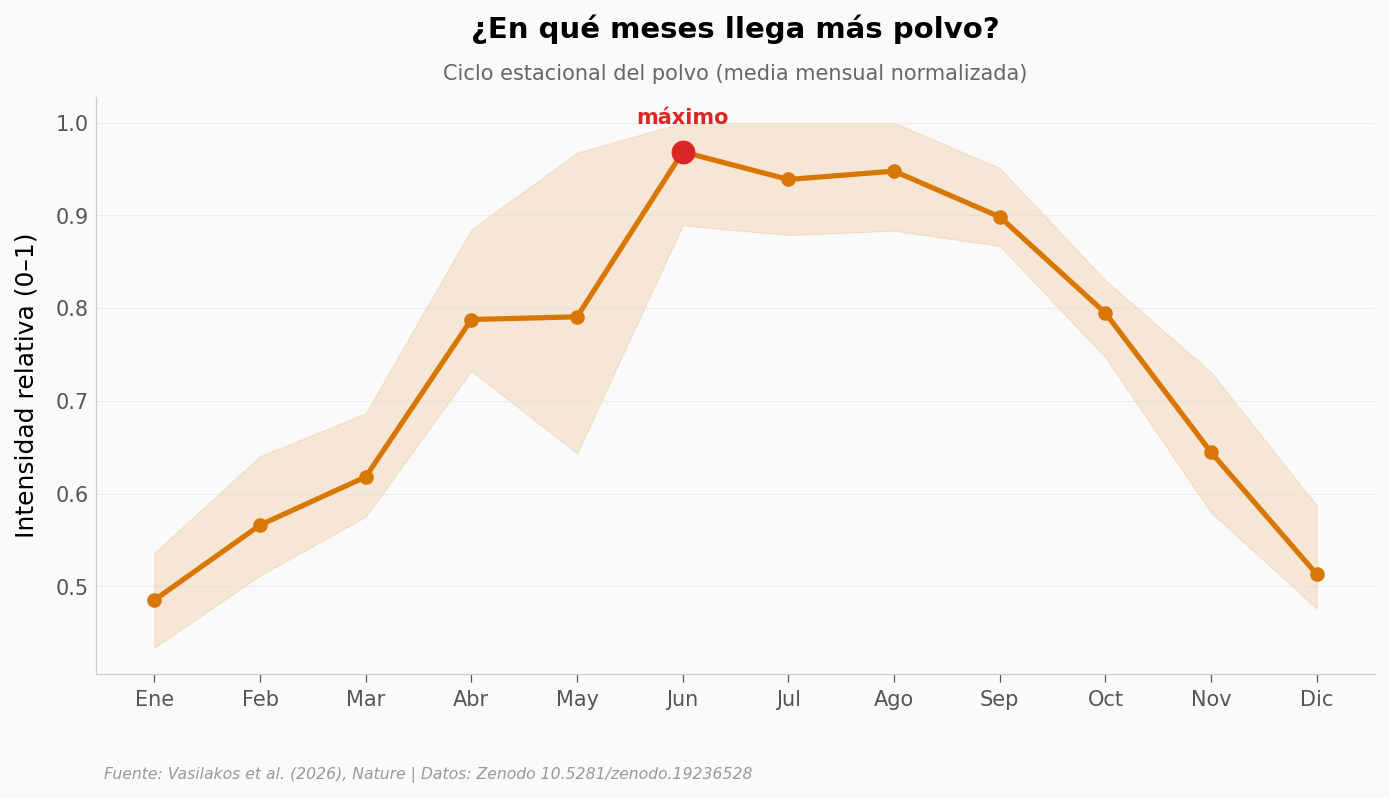

Pico del polvo: mes 6 (junio). Mínimo en pleno invierno.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# El polvo no llega parejo todo el año. Estas son medias mensuales normalizadas (0–1)
# promediadas sobre las bandas del estudio: el patrón estacional es robusto.
bandas = ['b1', 'b2', 'b3', 'b4', 'b5']
ciclo['media'] = ciclo[bandas].mean(axis=1)
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(ciclo.mes, ciclo[bandas].min(axis=1), ciclo[bandas].max(axis=1),
                color=COLOR_REF, alpha=0.15, zorder=1)
ax.plot(ciclo.mes, ciclo.media, color=COLOR_REF, linewidth=2.5,
        marker='o', markersize=6, zorder=4)
pico = int(ciclo.loc[ciclo.media.idxmax(), 'mes'])
ax.scatter([pico], [ciclo.media.max()], color=COLOR_SUR, s=120, zorder=5)
ax.text(pico, ciclo.media.max()+0.03, 'máximo', color=COLOR_SUR,
        fontsize=10, fontweight='bold', ha='center')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_title('¿En qué meses llega más polvo?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ciclo estacional del polvo (media mensual normalizada)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Intensidad relativa (0–1)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ciclo_estacional.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pico del polvo: mes {pico} (junio). Mínimo en pleno invierno.')

---

## Fuentes

**Paper**: [Rising dust pollution across Europe in a changing climate](https://doi.org/10.1038/s41586-026-10743-w)  
*Nature, 2026-07-15*

**Dataset canónico**: [Code and data for 'Rising dust pollution across Europe in a changing climate'](https://doi.org/10.5281/zenodo.19236528)  
*Zenodo — datos y código de las figuras del paper*

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook generado por **Ciencia a Mordiscos** · Licencia de datos: ver repositorio original en Zenodo.*
*Reproducible: [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-15-dust-pollution-europa/notebook.ipynb)*